```
Author: Joshua Ashkinaze
Description: Bayesian model estimating P(American adult ever engaged in SSL).
             Combines chatbot usage prevalence with SSL-given-chatbot-use prevalence
             from two sources (Study 1 survey and the meta-analytic review).

Inputs:
    - survey_est.json:  Weighted any-SSL prevalence from Study 1 survey (N=392 LLM users)
    - meta_est.json:    SSL prevalence from the meta-analytic review (N=16,253 effective participants)
    - usage_est.json:   Chatbot usage prevalence from the Elon University survey (N=500)
    - ../data/clean/benchmarks.csv: U.S. adult behavior benchmarks for comparison

Outputs:
    - ../plots/pop_prevalence_posterior.pdf: Bayesian posterior for P(SSL | American adult)
    - ../plots/pop_benchmarks_model.pdf:     SSL estimate compared to other U.S. adult behaviors
```

In [ ]:
####################
# Install CmdStanPy
####################




In [1]:
####################
# Imports
####################

import json
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import cmdstanpy as csp
import matplotlib.pyplot as plt
import seaborn as sns
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "study1" else Path.cwd()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from helpers import make_aesthetic


In [2]:
####################
# Data
####################

with open("survey_est.json") as f:
    survey = json.load(f)

with open("meta_est.json") as f:
    meta = json.load(f)

with open("usage_est.json") as f:
    usage = json.load(f)

# theta_usage  = P(ever used chatbot | American adult)   <- usage_est
# theta_ssl    = P(ever did SSL | chatbot user)          <- survey_est + meta_est
# p_ssl        = theta_usage * theta_ssl                 <- generated quantity

stan_data = {
    "n_usage":      usage["n"],
    "k_usage":      usage["effective_n"],
    "n_ssl_survey": survey["n"],
    "k_ssl_survey": survey["n_ssl"],
    "n_ssl_meta":   meta["n"],
    "k_ssl_meta":   meta["n_ssl"],
}

print(stan_data)


{'n_usage': 500, 'k_usage': 260, 'n_ssl_survey': 392, 'k_ssl_survey': 262, 'n_ssl_meta': 260, 'k_ssl_meta': 172}


In [3]:
####################
# Helpers
####################

def summarize_draws(draws, parameters, interval=0.95):
    lower_q = (1 - interval) / 2
    upper_q = 1 - lower_q
    rows = []
    for param in parameters:
        vals = draws[param].to_numpy()
        rows.append({
            "parameter": param,
            "mean":      vals.mean(),
            "sd":        vals.std(),
            f"lower_{int(interval * 100)}": np.quantile(vals, lower_q),
            f"upper_{int(interval * 100)}": np.quantile(vals, upper_q),
        })
    return pd.DataFrame(rows)


def wrap_text(text, width=30):
    try:
        return "\n".join(textwrap.wrap(str(text), width=width))
    except Exception:
        return text


In [4]:
####################
# Stan Model
####################

stan_code = """
data {
  int<lower=1> n_usage;
  int<lower=0, upper=n_usage> k_usage;

  int<lower=1> n_ssl_survey;
  int<lower=0, upper=n_ssl_survey> k_ssl_survey;

  int<lower=1> n_ssl_meta;
  int<lower=0, upper=n_ssl_meta> k_ssl_meta;
}

parameters {
  real<lower=0, upper=1> theta_usage;
  real<lower=0, upper=1> theta_ssl;
}

model {
  theta_usage ~ beta(2, 2);
  theta_ssl   ~ beta(2, 2);

  k_usage      ~ binomial(n_usage,      theta_usage);
  k_ssl_survey ~ binomial(n_ssl_survey, theta_ssl);
  k_ssl_meta   ~ binomial(n_ssl_meta,   theta_ssl);
}

generated quantities {
  real<lower=0, upper=1> p_ssl;
  p_ssl = theta_usage * theta_ssl;
}
"""

with open("ssl_pop_prevalence.stan", "w") as f:
    f.write(stan_code)

####################
# Fit Model
####################

model = csp.CmdStanModel(stan_file="ssl_pop_prevalence.stan")

fit = model.sample(
    data=stan_data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=2000,
    seed=123,
)


09:41:38 - cmdstanpy - INFO - compiling stan file /Users/jashkina/Documents/locresearch/LocResearch/ssl_wrapper/proj/ssl/study1/ssl_pop_prevalence.stan to exe file /Users/jashkina/Documents/locresearch/LocResearch/ssl_wrapper/proj/ssl/study1/ssl_pop_prevalence
09:41:44 - cmdstanpy - INFO - compiled model executable: /Users/jashkina/Documents/locresearch/LocResearch/ssl_wrapper/proj/ssl/study1/ssl_pop_prevalence
09:41:45 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

09:41:45 - cmdstanpy - INFO - CmdStan done processing.


In [5]:
####################
# Posterior Summary
####################

draws = fit.draws_pd()
summary = summarize_draws(draws, ["theta_usage", "theta_ssl", "p_ssl"])
display(summary)

####################
# Manuscript Values
####################

for name in ["theta_usage", "theta_ssl", "p_ssl"]:
    vals = draws[name].to_numpy()
    mean = vals.mean()
    lo, hi = np.quantile(vals, [0.025, 0.975])
    print(f"{name}: mean = {mean:.3f}, 95% CI = ({lo:.3f}, {hi:.3f})")


,parameter,mean,sd,lower_95,upper_95
0,theta_usage,0.519902,0.022004,0.478042,0.562784
1,theta_ssl,0.664826,0.018435,0.627688,0.701064
2,p_ssl,0.345638,0.017357,0.311926,0.380536


theta_usage: mean = 0.520, 95% CI = (0.478, 0.563)
theta_ssl: mean = 0.665, 95% CI = (0.628, 0.701)
p_ssl: mean = 0.346, 95% CI = (0.312, 0.381)


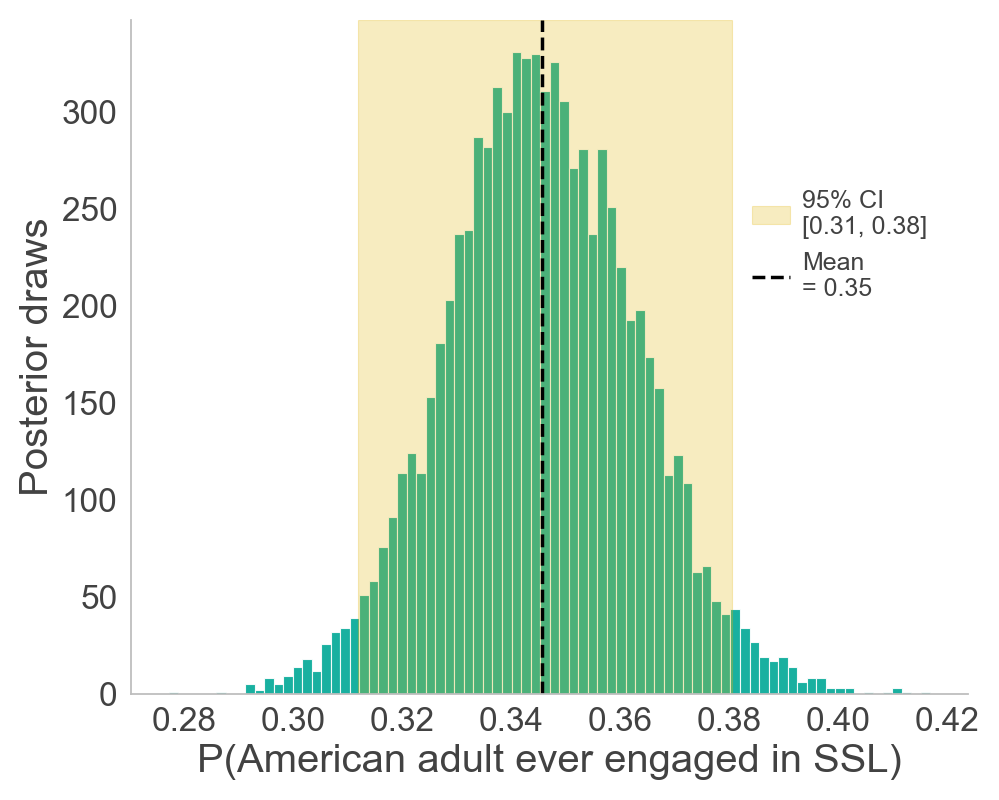

In [23]:
####################
# Plot 1: Bayesian Posterior
####################

mypal = make_aesthetic(font_scale=1.6)

p_ssl_samples = draws["p_ssl"].to_numpy()
mean_val      = p_ssl_samples.mean()
lo95, hi95    = np.quantile(p_ssl_samples, [0.025, 0.975])

fig, ax = plt.subplots(figsize=(10, 8))

ax.hist(p_ssl_samples, bins=80, color=mypal[0], edgecolor="white", alpha=0.9)
ax.axvspan(lo95, hi95, alpha=0.25, color=mypal[2],
           label=f"95% CI\n[{lo95:.2f}, {hi95:.2f}]")
ax.axvline(mean_val, color="black", lw=2.5, linestyle="--",
           label=f"Mean\n= {mean_val:.2f}")
ax.set_xlabel("P(American adult ever engaged in SSL)")
ax.set_ylabel("Posterior draws")
ax.legend(frameon=False, fontsize=18, bbox_to_anchor=(0.7, 0.8))
sns.despine(ax=ax)

fig.savefig("../plots/pop_prevalence_posterior.pdf", dpi=300, bbox_inches="tight")
plt.show()


/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_92498/2349081895.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="percentage", y="short_version_wrap", data=use, palette=colors, ax=ax)


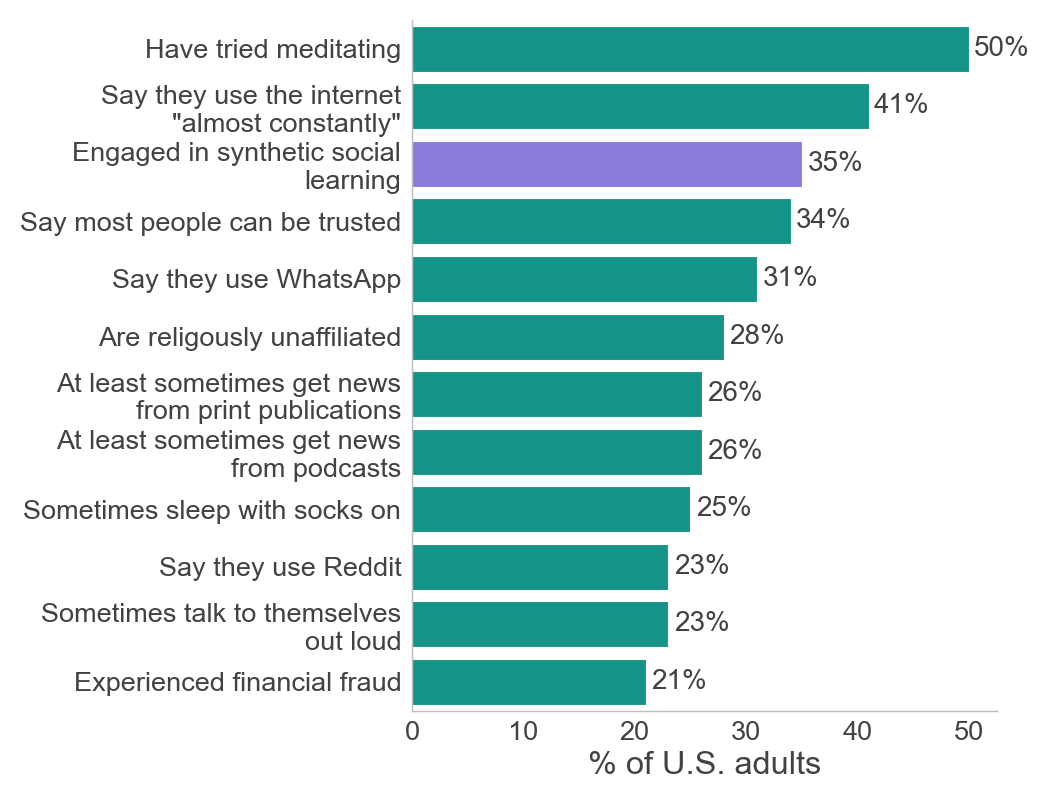

In [28]:
####################
# Plot 2: Benchmarks
####################


mypal = make_aesthetic(font_scale=1.3)

bench = pd.read_csv("../data/clean/benchmarks.csv")
use = bench[bench["flag(positive)"] > 0].copy()

ssl_pct = float(np.round(mean_val * 100, 0))
use["percentage"] = use["percentage"].apply(lambda x: ssl_pct if x < 0 else x)
use = use.dropna(subset=["short_version"])
use["short_version_wrap"] = use["short_version"].apply(lambda x: wrap_text(x, width=30))
use = use.sort_values("percentage", ascending=False)

colors = [
    mypal[1] if "synthetic social learning" in str(row["short_version"]).lower() else mypal[0]
    for _, row in use.iterrows()
]

fig, ax = plt.subplots(figsize=(10.5, 8))
sns.barplot(x="percentage", y="short_version_wrap", data=use, palette=colors, ax=ax)
ax.set_xlabel("% of U.S. adults")
ax.set_ylabel("")

for i, (idx, row) in enumerate(use.iterrows()):
    ax.text(row["percentage"] + 0.5, i, f"{row['percentage']:.0f}%",
            va="center", fontsize=20)

sns.despine(ax=ax)
fig.savefig("../plots/pop_benchmarks_model.pdf", dpi=300, bbox_inches="tight")
plt.show()
